## Iterative Training of the Structural Phase Classifier

This notebook trains and evaluates XGBoost classifiers for the structural
phase label using datasets from iterations 3–6.

### Workflow

1. Independently split each dataset into stratified training/test sets (80/20).
2. Fit a scaler on training data and select the top 15 features.
3. Train classifiers and evaluate predictions using a fixed threshold of 0.7.
4. Export ROC data, models, scalers, selected features, and performance metrics.

Labels are expected to be encoded as 0 and 1. Splits are row-based;
this notebook does not perform cross-validation or compound-group splitting.
Run the code cells sequentially.

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_label.csv",
    "Iteration_4": "data/compound_4_Structural_label.csv",
    "Iteration_5": "data/compound_5_Structural_label.csv",
    "Iteration_6": "data/compound_6_Structural_label.csv"
}

LABEL_COL = "label"
COMPOUND_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features and label
    X = (
        data
        .drop(
            columns=[
                LABEL_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    y = (
        data[LABEL_COL]
        .astype(int)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    # Standardization
    scaler = StandardScaler()

    X_train_scale = scaler.fit_transform(
        X_train
    )

    X_test_scale = scaler.transform(
        X_test
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_scale": X_train_scale,
        "X_test_scale": X_test_scale,
        "scaler": scaler
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print("\nTraining label distribution:")
    print(
        y_train.value_counts()
        .sort_index()
    )

    print("\nTest label distribution:")
    print(
        y_test.value_counts()
        .sort_index()
    )


Iteration_3
Dataset shape: (125, 27)
Training samples: 100
Test samples: 25

Training label distribution:
0    66
1    34
Name: label, dtype: int64

Test label distribution:
0    17
1     8
Name: label, dtype: int64

Iteration_4
Dataset shape: (133, 27)
Training samples: 106
Test samples: 27

Training label distribution:
0    73
1    33
Name: label, dtype: int64

Test label distribution:
0    18
1     9
Name: label, dtype: int64

Iteration_5
Dataset shape: (145, 27)
Training samples: 116
Test samples: 29

Training label distribution:
0    75
1    41
Name: label, dtype: int64

Test label distribution:
0    19
1    10
Name: label, dtype: int64

Iteration_6
Dataset shape: (160, 27)
Training samples: 128
Test samples: 32

Training label distribution:
0    84
1    44
Name: label, dtype: int64

Test label distribution:
0    21
1    11
Name: label, dtype: int64


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    X_train_scale = iteration["X_train_scale"]
    X_test_scale = iteration["X_test_scale"]


    # Calculate class weight
    scale_pos_weight = (
        (y_train == 0).sum()
        / (y_train == 1).sum()
    )


    # Initial model for feature selection
    clf_selector = XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    clf_selector.fit(
        X_train_scale,
        y_train
    )


    # Extract feature importance
    feature_importance = (
        clf_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )


    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )


    # Select training and test features
    X_train_selected = (
        X_train_scale[:, top_idx]
    )

    X_test_selected = (
        X_test_scale[:, top_idx]
    )


    # Store feature-selection results
    iteration["scale_pos_weight"] = (
        scale_pos_weight
    )

    iteration["clf_selector"] = (
        clf_selector
    )

    iteration["selected_features"] = (
        selected_features
    )

    iteration["top_idx"] = (
        top_idx
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)

D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_3
Selected features:
['C_AN', 'AB_AW', 'AB_AN', 'AB_SIE', 'AB_AR', 'AB_CR', 'AB_TC', 'AB_FIE', 'AB_EA', 'C_CR', 'AB_Nv', 'AB_D', 'AB_Nd', 'AB_EC', 'AB_EN']


D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_4
Selected features:
['AB_AR', 'AB_AW', 'AB_AN', 'AB_TC', 'C_AW', 'AB_SIE', 'AB_FIE', 'AB_CR', 'C_AN', 'C_CR', 'AB_EC', 'AB_Nv', 'AB_EA', 'AB_EN', 'AB_Nd']


D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_5
Selected features:
['C_EA', 'AB_AN', 'AB_SIE', 'AB_FIE', 'AB_Nv', 'AB_CR', 'C_CR', 'AB_AW', 'AB_EC', 'AB_EA', 'AB_TC', 'AB_D', 'AB_AR', 'AB_EN', 'C_FIE']


D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_6
Selected features:
['C_EA', 'AB_SIE', 'AB_AW', 'AB_CR', 'AB_FIE', 'AB_AN', 'C_CR', 'AB_AR', 'AB_TC', 'AB_EA', 'AB_Nv', 'AB_D', 'AB_EC', 'C_FIE', 'AB_EN']



Iteration_3
Classification threshold: 0.7

Model performance:
       Accuracy  Precision  Recall      F1  ROC_AUC
Train      0.95     1.0000  0.8529  0.9206   0.9989
Test       0.64     0.4444  0.5000  0.4706   0.7132

Test classification report:
              precision    recall  f1-score   support

           0     0.7500    0.7059    0.7273        17
           1     0.4444    0.5000    0.4706         8

    accuracy                         0.6400        25
   macro avg     0.5972    0.6029    0.5989        25
weighted avg     0.6522    0.6400    0.6451        25



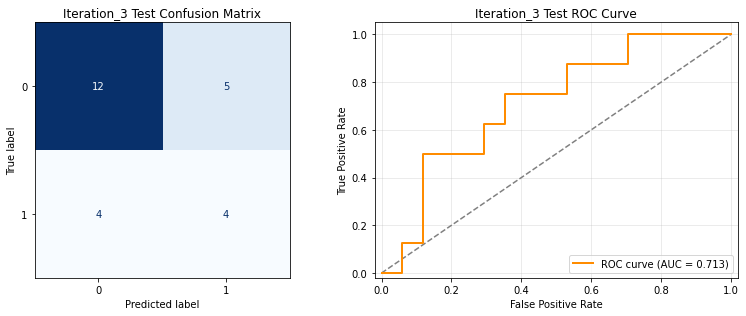

D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_4
Classification threshold: 0.7

Model performance:
       Accuracy  Precision  Recall     F1  ROC_AUC
Train    0.9528     1.0000  0.8485  0.918   0.9981
Test     0.6296     0.4286  0.3333  0.375   0.7222

Test classification report:
              precision    recall  f1-score   support

           0     0.7000    0.7778    0.7368        18
           1     0.4286    0.3333    0.3750         9

    accuracy                         0.6296        27
   macro avg     0.5643    0.5556    0.5559        27
weighted avg     0.6095    0.6296    0.6162        27



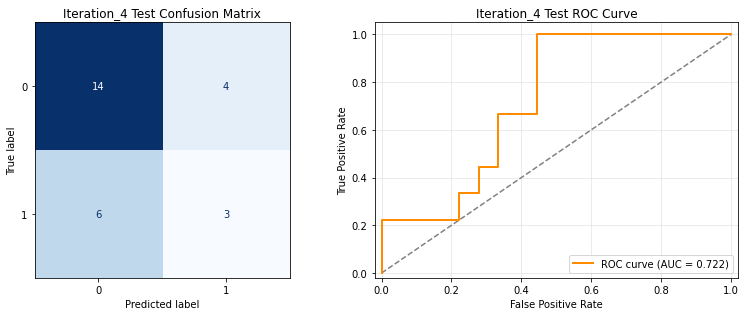

D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_5
Classification threshold: 0.7

Model performance:
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.9569     1.0000   0.878  0.9351   0.9995
Test     0.7241     0.5833   0.700  0.6364   0.8447

Test classification report:
              precision    recall  f1-score   support

           0     0.8235    0.7368    0.7778        19
           1     0.5833    0.7000    0.6364        10

    accuracy                         0.7241        29
   macro avg     0.7034    0.7184    0.7071        29
weighted avg     0.7407    0.7241    0.7290        29



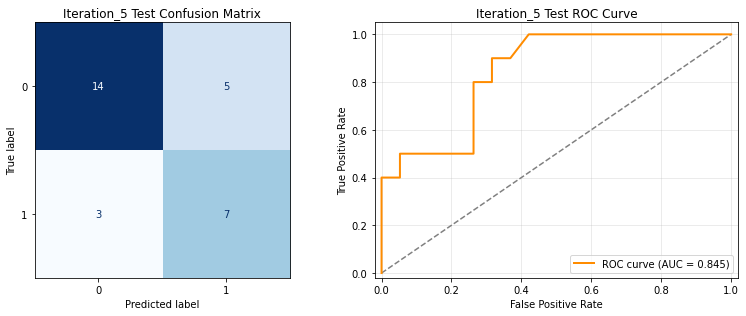

D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)



Iteration_6
Classification threshold: 0.7

Model performance:
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.9531     0.9524  0.9091  0.9302   0.9947
Test     0.8438     0.8000  0.7273  0.7619   0.7835

Test classification report:
              precision    recall  f1-score   support

           0     0.8636    0.9048    0.8837        21
           1     0.8000    0.7273    0.7619        11

    accuracy                         0.8438        32
   macro avg     0.8318    0.8160    0.8228        32
weighted avg     0.8418    0.8438    0.8418        32



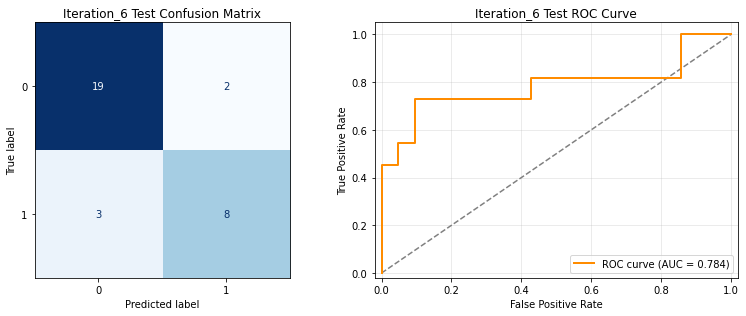

In [4]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

CLASSIFICATION_THRESHOLD = 0.7

os.makedirs(
    "figure/label_iterations",
    exist_ok=True
)


# Calculate classification metrics
def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }


# Store the metrics from all iterations
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    scale_pos_weight = (
        iteration["scale_pos_weight"]
    )


    # --------------------------------------------------------
    # Train the final model
    # --------------------------------------------------------

    clf = XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    clf.fit(
        X_train_selected,
        y_train
    )


    # --------------------------------------------------------
    # Predict probabilities
    # --------------------------------------------------------

    train_prob = clf.predict_proba(
        X_train_selected
    )[:, 1]

    test_prob = clf.predict_proba(
        X_test_selected
    )[:, 1]


    # Apply the classification threshold
    train_pred = (
        train_prob
        >= CLASSIFICATION_THRESHOLD
    ).astype(int)

    test_pred = (
        test_prob
        >= CLASSIFICATION_THRESHOLD
    ).astype(int)


    # --------------------------------------------------------
    # Calculate model metrics
    # --------------------------------------------------------

    train_metrics = calculate_metrics(
        y_train,
        train_pred,
        train_prob
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred,
        test_prob
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print(
        "Classification threshold:",
        CLASSIFICATION_THRESHOLD
    )

    print("\nModel performance:")
    print(
        metrics_table.round(4)
    )

    print("\nTest classification report:")
    print(
        classification_report(
            y_test,
            test_pred,
            digits=4,
            zero_division=0
        )
    )


    # Store train metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        "Threshold": CLASSIFICATION_THRESHOLD,
        **train_metrics
    })

    # Store test metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        "Threshold": CLASSIFICATION_THRESHOLD,
        **test_metrics
    })


    # Store model results
    iteration["clf"] = clf
    iteration["train_prob"] = train_prob
    iteration["test_prob"] = test_prob
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics
    iteration["metrics_table"] = metrics_table


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        test_pred
    )

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=clf.classes_
    )

    cm_display.plot(
        ax=axes[0],
        cmap="Blues",
        colorbar=False
    )

    axes[0].set_title(
        f"{iteration_name} Test Confusion Matrix"
    )


    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(
        y_test,
        test_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    axes[1].plot(
        fpr,
        tpr,
        color="darkorange",
        linewidth=2,
        zorder=5,
        label=(
            f"ROC curve "
            f"(AUC = {roc_auc:.3f})"
        )
    )

    axes[1].plot(
        [0, 1],
        [0, 1],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlim([-0.02, 1.02])
    axes[1].set_ylim([-0.02, 1.05])

    axes[1].set_xlabel(
        "False Positive Rate"
    )

    axes[1].set_ylabel(
        "True Positive Rate"
    )

    axes[1].set_title(
        f"{iteration_name} Test ROC Curve"
    )

    axes[1].legend(
        loc="lower right"
    )

    axes[1].grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [7]:
# ============================================================
# 5. Save ROC curve data
# ============================================================

os.makedirs(
    "result/label_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    y_test = iteration["y_test"]
    test_prob = iteration["test_prob"]

    fpr, tpr, roc_thresholds = roc_curve(
        y_test,
        test_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    roc_data = pd.DataFrame({
        "False_Positive_Rate": fpr,
        "True_Positive_Rate": tpr,
        "Threshold": roc_thresholds,
        "ROC_AUC": roc_auc
    })

    roc_data.to_csv(
        (
            "result/label_iterations/"
            f"Iteration_{iteration_number}_ROC_curve_data.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} ROC curve data saved."
    )

Iteration_3 ROC curve data saved.
Iteration_4 ROC curve data saved.
Iteration_5 ROC curve data saved.
Iteration_6 ROC curve data saved.


In [6]:
# ============================================================
# 5. Save models, scalers, selected features and metrics
# ============================================================

os.makedirs(
    "model/label_iterations",
    exist_ok=True
)

os.makedirs(
    "result/label_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    # Get iteration number
    iteration_number = (
        iteration_name.split("_")[-1]
    )

    clf = iteration["clf"]
    scaler = iteration["scaler"]

    selected_features = (
        iteration["selected_features"]
    )


    # Save model
    joblib.dump(
        clf,
        (
            "model/label_iterations/"
            f"xgb_structural_label_{iteration_number}.pkl"
        )
    )


    # Save scaler
    joblib.dump(
        scaler,
        (
            "model/label_iterations/"
            f"scaler_structural_label_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/label_iterations/"
            f"selected_features_structural_label_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )

    print(
        f"{iteration_name} model files saved."
    )


# Save all model metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/label_iterations/"
    "structural_label_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 model files saved.
Iteration_4 model files saved.
Iteration_5 model files saved.
Iteration_6 model files saved.

Test performance comparison
     Iteration Dataset  Sample_Size  Threshold  Accuracy  Precision  Recall  \
0  Iteration_3    Test           25        0.7    0.6400     0.4444  0.5000   
1  Iteration_4    Test           27        0.7    0.6296     0.4286  0.3333   
2  Iteration_5    Test           29        0.7    0.7241     0.5833  0.7000   
3  Iteration_6    Test           32        0.7    0.8438     0.8000  0.7273   

       F1  ROC_AUC  
0  0.4706   0.7132  
1  0.3750   0.7222  
2  0.6364   0.8447  
3  0.7619   0.7835  
